In [1]:
# In questo notepad verrà definita l'architettura dell GCN.
# L'obiettivo è produrre degli embedding sul quale fare clustering.

from torch_geometric.data import Data
import torch

OUTPUT_PATH = './model_output'

pre_processed_data_path = f'{OUTPUT_PATH}/pre_processed_data.pt'
pre_processed_data_path_ctd = f'{OUTPUT_PATH}/pre_processed_data_ctd.pt'

data = torch.load(pre_processed_data_path)
ctd_data = torch.load(pre_processed_data_path_ctd)

edge_index = data['edge_index']
node_features = data['node_features']
node_ids = data['node_ids']

edge_index_ctd = ctd_data['edge_index']
node_features_ctd = ctd_data['node_features']
node_ids_ctd = ctd_data['node_ids']

data = Data(x=node_features, edge_index=edge_index)
ctd_data = Data(x=node_features_ctd, edge_index=edge_index_ctd)

print(data)
print(ctd_data)

/home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/libpyg.so: undefined symbol: _ZN3c1010Dispatcher17runRecordFunctionERN2at14RecordFunctionESt17reference_wrapperIKNS_14FunctionSchemaEENS_11DispatchKeyE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/torch_scatter/_version_cpu.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/developer/Documents/Tesi/code/.venv/lib/python3.12/site-packages/torch_geometric/typing

Data(x=[178, 200], edge_index=[2, 663])
Data(x=[172, 200], edge_index=[2, 634])


In [10]:
print("DEBUG INFOs")

print("Numero totale di nodi in x:", node_features.shape[0])  # Deve essere 178
print("Massimo ID presente in edge_index:", edge_index.max().item())  # Non deve essere >= 178
print("Minimo ID presente in edge_index:", edge_index.min().item())  # Non deve essere < 0

print("Numero totale di nodi in x:", node_features_ctd.shape[0])  # Deve essere 178
print("Massimo ID presente in edge_index:", edge_index_ctd.max().item())  # Non deve essere >= 178
print("Minimo ID presente in edge_index:", edge_index_ctd.min().item())  # Non deve essere < 0


DEBUG INFOs
Numero totale di nodi in x: 178
Massimo ID presente in edge_index: 177
Minimo ID presente in edge_index: 0
Numero totale di nodi in x: 172
Massimo ID presente in edge_index: 171
Minimo ID presente in edge_index: 0


In [3]:
# Definizione architettura

import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, embedding_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)  # Primo strato di convoluzione
        self.conv2 = GCNConv(hidden_channels, embedding_dim)  # Strato finale per generare gli embedding

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)  # Attivazione non lineare
        x = self.conv2(x, edge_index)  # Gli embedding finali
        return x  # Ritorniamo direttamente gli embedding

# Inizializziamo il modello
model = GCN(in_channels=node_features.shape[1], hidden_channels=64, embedding_dim=16)
model_ctd = GCN(in_channels=node_features_ctd.shape[1], hidden_channels=64, embedding_dim=16)

print(model)
print(model_ctd)


GCN(
  (conv1): GCNConv(200, 64)
  (conv2): GCNConv(64, 16)
)
GCN(
  (conv1): GCNConv(200, 64)
  (conv2): GCNConv(64, 16)
)


In [108]:
# Training

import torch.optim as optim
from tqdm import tqdm

optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0)

# Loss basata sulla similarità dei nodi connessi
def unsupervised_loss(embeddings, edge_index):
    node1 = embeddings[edge_index[0]]
    node2 = embeddings[edge_index[1]]
    return F.mse_loss(node1, node2)

def train_model(model, num_epochs, data):
    with tqdm(total=num_epochs, desc="Training Progress", unit="epoch") as pbar:
        for _ in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            embeddings = model(data)
            loss = unsupervised_loss(embeddings, data.edge_index)
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=loss.item())
            pbar.update(1)
    model.eval()
    return model(data)

num_epochs = 1000
embeddings = train_model(model, num_epochs, data)
embeddings_ctd = train_model(model_ctd, num_epochs, ctd_data)

import numpy as np

np.savez(f"{OUTPUT_PATH}/embeddings.npz", embeddings=embeddings.detach().cpu().numpy())
print("Embeddings salvati in `embeddings.npz`")

Training Progress: 100%|██████████| 1000/1000 [00:03<00:00, 284.01epoch/s, loss=0.0206]


Embeddings salvati in `embeddings.npz`


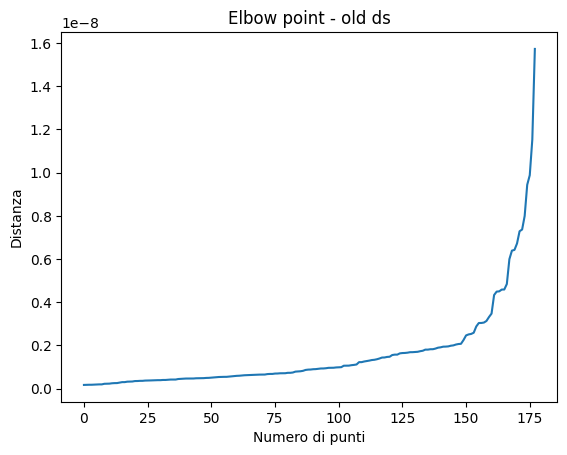

In [94]:
# Cerco un valore ottimale per il parametro eps di DBSCAN usando la tecnica dell'elbow point

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings.detach().cpu().numpy())

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(embeddings_pca)
distances, indices = neighbors_fit.kneighbors(embeddings_pca)

# Ordiniamo le distanze del 5° vicino più vicino
distances = np.sort(distances[:, 4], axis=0)

plt.plot(distances)
plt.xlabel("Numero di punti")
plt.ylabel("Distanza")
plt.title("Elbow point - old ds")
plt.show()


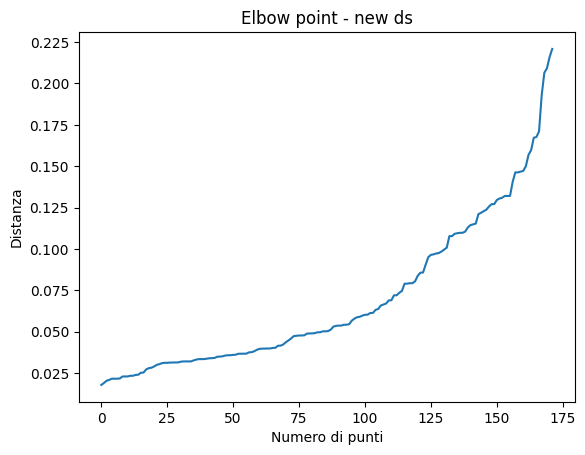

In [95]:
# Cerco un valore ottimale per il parametro eps di DBSCAN usando la tecnica dell'elbow point

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_ctd.detach().cpu().numpy())

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(embeddings_pca)
distances, indices = neighbors_fit.kneighbors(embeddings_pca)

# Ordiniamo le distanze del 5° vicino più vicino
distances = np.sort(distances[:, 4], axis=0)

plt.plot(distances)
plt.xlabel("Numero di punti")
plt.ylabel("Distanza")
plt.title("Elbow point - new ds")
plt.show()


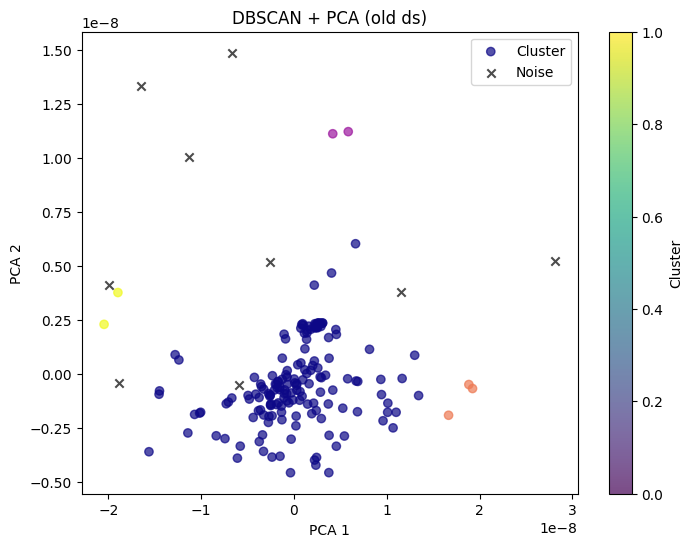

Numero di punti per cluster
0)	162
1)	2
2)	3
3)	2
Noise)	9


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=0.4e-8, min_samples=2)
clusters = dbscan.fit_predict(embeddings.detach().cpu().numpy())

# Riduzione con PCA
pca = PCA(n_components=2)
embeddings_2D = pca.fit_transform(embeddings.detach().cpu().numpy())

# Separa noisy points per visualization
noise_mask = clusters == -1
cluster_mask = ~noise_mask 

plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(embeddings_2D[cluster_mask, 0], embeddings_2D[cluster_mask, 1], 
            c=clusters[cluster_mask], cmap="plasma", alpha=0.7, marker='o', label="Cluster")

# Plot noise
plt.scatter(embeddings_2D[noise_mask, 0], embeddings_2D[noise_mask, 1], 
            color="black", alpha=0.7, marker='x', label="Noise")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN + PCA (old ds)")
plt.legend()
plt.colorbar(label="Cluster")
plt.show()

# Info
print("Numero di punti per cluster")
for i in range(max(clusters) + 1):
    print(f"{i})\t{len(clusters[clusters == i])}")

print(f"Noise)\t{len(clusters[clusters == -1])}")


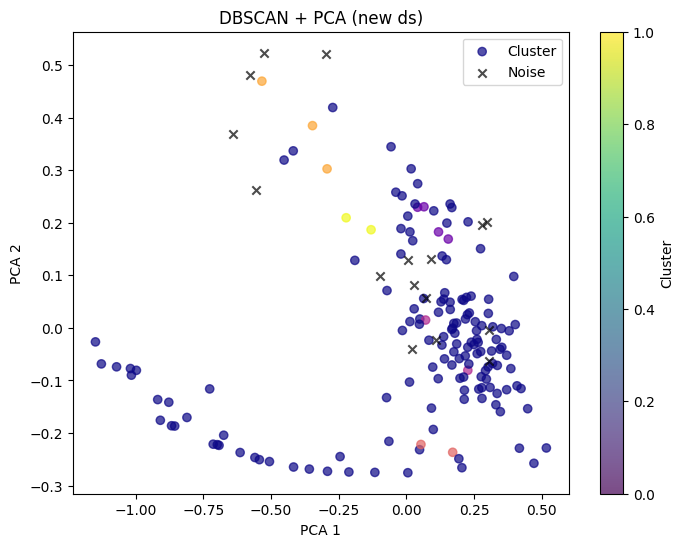

Numero di punti per cluster
0)	143
1)	4
2)	2
3)	2
4)	3
5)	2
Noise)	16


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

dbscan = DBSCAN(eps=0.35, min_samples=2)
clusters_ctd = dbscan.fit_predict(embeddings_ctd.detach().cpu().numpy())

pca = PCA(n_components=2)
embeddings_2D = pca.fit_transform(embeddings_ctd.detach().cpu().numpy())

noise_mask = clusters_ctd == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(8,6))

plt.scatter(embeddings_2D[cluster_mask, 0], embeddings_2D[cluster_mask, 1], 
            c=clusters_ctd[cluster_mask], cmap="plasma", alpha=0.7, marker='o', label="Cluster")

plt.scatter(embeddings_2D[noise_mask, 0], embeddings_2D[noise_mask, 1], 
            color="black", alpha=0.7, marker='x', label="Noise")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DBSCAN + PCA (new ds)")
plt.legend()
plt.colorbar(label="Cluster")
plt.show()

print("Numero di punti per cluster")
for i in range(max(clusters_ctd) + 1):
    print(f"{i})\t{len(clusters_ctd[clusters_ctd == i])}")

print(f"Noise)\t{len(clusters_ctd[clusters_ctd == -1])}")
